# 01 — Ingest

Load the Strava bulk export, filter to **Run / Ride / Hike** activities up to and including the marathon on **2026-04-12**, then for each qualifying activity:

1. Extract the (possibly `.gz`-compressed) source file in memory.
2. Convert to a GPX (Garmin `TrackPointExtension` schema preserving HR & cadence) and write it to `data/activities/<discipline>/<activity_id>.gpx` — this is our durable, format-uniform intermediate dataset.
3. Parse the GPXs into a per-second long-format `streams.parquet`, and compute per-second grade-adjusted speed (`gap_speed_mps`) so elevation can be neutralised when modelling race pace.

Outputs:

| Path | Contents |
| --- | --- |
| `data/activities/{running,cycling,hiking}/<id>.gpx` | GPX |
| `data/raw/activities_raw.parquet` | One row per kept activity (summary fields from `activities.csv`) |
| `data/streams/streams.parquet` | Per-second long-format streams (HR, cadence, speed, ele, GAP) |

Run from a kernel using the project's `.venv`.


In [1]:
import gzip
import math
import xml.etree.ElementTree as ET
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
from fitparse import FitFile
from tqdm.auto import tqdm

PROJECT_ROOT = Path.cwd()
assert PROJECT_ROOT.name == "Project", f"Run from Project/, not {PROJECT_ROOT}"

REPO_ROOT = PROJECT_ROOT.parent
EXPORT_ROOT = REPO_ROOT.parent / "Strava-Export"
ACT_DIR = EXPORT_ROOT / "activities"
DATA_DIR = PROJECT_ROOT / "data"

# Discipline subfolders for canonical GPX
ACTIVITY_TYPE_TO_DISCIPLINE = {"Run": "running", "Ride": "cycling", "Hike": "hiking"}

(DATA_DIR / "raw").mkdir(parents=True, exist_ok=True)
(DATA_DIR / "streams").mkdir(parents=True, exist_ok=True)
for d in ACTIVITY_TYPE_TO_DISCIPLINE.values():
    (DATA_DIR / "activities" / d).mkdir(parents=True, exist_ok=True)

# Hard cap: marathon day end-of-day UTC
CUTOFF = pd.Timestamp("2026-04-12 23:59:59", tz="UTC")

assert EXPORT_ROOT.exists(), f"Strava export not found at {EXPORT_ROOT}"
print("Export root:", EXPORT_ROOT)
print("Cutoff:", CUTOFF)


Export root: /Users/as/Library/Mobile Documents/com~apple~CloudDocs/Dokumente/Studium/Master-26-FS/Big Data Methods for Economists/Strava-Export
Cutoff: 2026-04-12 23:59:59+00:00


## 1.1 Load and clean the activity summary

`activities.csv` repeats some fields with numeric suffixes (`Distance3`, `Max Heart Rate4`, `Relative Effort5`). We coalesce them onto a single canonical name. Rows with no `Filename` are dropped.


In [2]:
activities = pd.read_csv(EXPORT_ROOT / "activities.csv", low_memory=False)
print("Raw shape:", activities.shape)

DUPLICATE_COALESCE = {
    "Elapsed Time":   "Elapsed Time2",
    "Distance":       "Distance3",
    "Max Heart Rate": "Max Heart Rate4",
    "Relative Effort": "Relative Effort5",
}
for canonical, alt in DUPLICATE_COALESCE.items():
    if alt in activities.columns:
        activities[canonical] = pd.to_numeric(activities[canonical], errors="coerce") \
            .combine_first(pd.to_numeric(activities[alt], errors="coerce"))
        activities = activities.drop(columns=[alt])

activities["activity_id"] = activities["Activity ID"].astype("int64")
activities["activity_dt"] = pd.to_datetime(
    activities["Activity Date"], format="%b %d, %Y, %I:%M:%S %p", utc=True
)
print(activities[["activity_id", "Activity Type", "activity_dt", "Filename"]].head())


Raw shape: (767, 103)
   activity_id Activity Type               activity_dt  \
0  18358418723          Ride 2026-05-03 08:55:31+00:00   
1  18335876950          Ride 2026-05-01 14:55:34+00:00   
2  18306562421          Ride 2026-04-29 12:13:30+00:00   
3  18251609113          Ride 2026-04-25 09:27:46+00:00   
4  18172676095           Run 2026-04-19 12:43:51+00:00   

                        Filename  
0  activities/19462553365.fit.gz  
1  activities/19439681858.fit.gz  
2  activities/19410121820.fit.gz  
3  activities/19354643473.fit.gz  
4  activities/19275110730.fit.gz  


## 1.2 Filter to Run / Ride / Hike, cap at marathon day

The supervised target downstream is **marathon finish time at 100 % effort**. Cycling and hiking are kept as cross-training context: GPS-bearing aerobic work that contributes to fitness state on race day. Everything else (swims, ski, gym, yoga) is dropped.


In [3]:
kept = activities[activities["Activity Type"].isin(ACTIVITY_TYPE_TO_DISCIPLINE)].copy()
kept = kept[kept["activity_dt"] <= CUTOFF]
kept = kept.dropna(subset=["Filename"]).drop_duplicates(subset=["activity_id"])
kept["discipline"] = kept["Activity Type"].map(ACTIVITY_TYPE_TO_DISCIPLINE)
kept["abs_path"] = kept["Filename"].apply(lambda f: EXPORT_ROOT / f)

# Drop rows whose referenced file has been physically removed (rare).
existing = kept[kept["abs_path"].apply(Path.exists)].copy()
kept = existing.sort_values("activity_dt").reset_index(drop=True)

print("After filter:", len(kept), "activities")
print(kept.groupby("discipline").size().rename("count"))
print("Date range:", kept["activity_dt"].min(), "→", kept["activity_dt"].max())


After filter: 673 activities
discipline
cycling     49
hiking      13
running    611
Name: count, dtype: int64
Date range: 2019-10-18 10:52:43+00:00 → 2026-04-12 06:16:06+00:00


## 1.3 Source-file readers and canonical extended-GPX writer

The export contains `.fit`, `.fit.gz`, `.gpx`, `.gpx.gz`. We read each transparently, normalise into a single in-memory record schema, then emit one extended-GPX file with HR / cadence / power inside the standard Garmin `<gpxtpx:TrackPointExtension>` block. Once written, every downstream notebook reads from `data/activities/<discipline>/` only — the raw export is touched exactly once.

**Why extended GPX?** Plain GPX 1.1 only carries `<lat>`, `<lon>`, `<ele>`, `<time>`. The Garmin `TrackPointExtension` namespace adds `<gpxtpx:hr>`, `<gpxtpx:cad>`, `<gpxtpx:atemp>` and an optional `<power>` element. This is the de-facto interchange format and `gpxpy >= 1.6` parses it natively.


In [4]:
SEMICIRCLE_TO_DEG = 180.0 / 2**31

GPX_NS    = "http://www.topografix.com/GPX/1/1"
GPXTPX_NS = "http://www.garmin.com/xmlschemas/TrackPointExtension/v1"
ET.register_namespace("",       GPX_NS)
ET.register_namespace("gpxtpx", GPXTPX_NS)


def open_maybe_gz(p: Path):
    return gzip.open(p, "rb") if p.suffix == ".gz" else open(p, "rb")


def file_kind(p: Path) -> str:
    stem = p.name.lower().removesuffix(".gz")
    if stem.endswith(".fit"): return "fit"
    if stem.endswith(".gpx"): return "gpx"
    return "unknown"


def _haversine_step(lat1, lon1, lat2, lon2):
    R = 6371000.0
    lat1, lat2 = np.radians(lat1), np.radians(lat2)
    dlat = lat2 - lat1
    dlon = np.radians(lon2 - lon1)
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))


def read_fit_records(path: Path) -> list[dict]:
    """Decode FIT 'record' messages into a uniform list-of-dict schema."""
    with open_maybe_gz(path) as fh:
        fit = FitFile(fh.read())
    out = []
    for msg in fit.get_messages("record"):
        d = {f.name: f.value for f in msg}
        ts = d.get("timestamp")
        if ts is None:
            continue
        lat = d.get("position_lat")
        lon = d.get("position_long")
        cad = d.get("cadence")
        frac = d.get("fractional_cadence") or 0
        cadence = (cad + frac) * 2 if cad is not None else None  # spm for running
        out.append({
            "t": pd.Timestamp(ts, tz="UTC"),
            "lat": lat * SEMICIRCLE_TO_DEG if lat is not None else None,
            "lon": lon * SEMICIRCLE_TO_DEG if lon is not None else None,
            "ele_m": d.get("enhanced_altitude") if d.get("enhanced_altitude") is not None else d.get("altitude"),
            "dist_m": d.get("distance"),
            "speed_mps": d.get("enhanced_speed") if d.get("enhanced_speed") is not None else d.get("speed"),
            "hr_bpm": d.get("heart_rate"),
            "cadence_rpm": cadence,
            "power_w": d.get("power"),
            "temp_c": d.get("temperature"),
        })
    return out


def read_gpx_records(path: Path) -> list[dict]:
    """Decode any GPX (plain or extended) into the same schema."""
    with open_maybe_gz(path) as fh:
        tree = ET.parse(fh)
    root = tree.getroot()
    base_ns = root.tag.split("}")[0].strip("{") if "}" in root.tag else GPX_NS
    ns = {"g": base_ns, "gpxtpx": GPXTPX_NS}
    pts = root.findall(".//g:trkpt", ns)
    out = []
    for pt in pts:
        ele = pt.find("g:ele", ns)
        tm  = pt.find("g:time", ns)
        ext = pt.find("g:extensions", ns)
        hr = cad = power = temp = None
        if ext is not None:
            tpx = ext.find("gpxtpx:TrackPointExtension", ns)
            if tpx is not None:
                for tag, key in [("gpxtpx:hr", "hr"), ("gpxtpx:cad", "cad"),
                                 ("gpxtpx:atemp", "temp")]:
                    el = tpx.find(tag, ns)
                    if el is not None and el.text:
                        v = float(el.text)
                        if key == "hr":   hr = v
                        if key == "cad":  cad = v
                        if key == "temp": temp = v
            pw = ext.find("g:power", ns)  # power lives directly under extensions
            if pw is not None and pw.text:
                power = float(pw.text)
        out.append({
            "t": pd.to_datetime(tm.text, utc=True) if tm is not None and tm.text else None,
            "lat": float(pt.get("lat")) if pt.get("lat") else None,
            "lon": float(pt.get("lon")) if pt.get("lon") else None,
            "ele_m": float(ele.text) if ele is not None and ele.text else None,
            "dist_m": None,        # filled by haversine cumsum below
            "speed_mps": None,
            "hr_bpm": hr,
            "cadence_rpm": cad,
            "power_w": power,
            "temp_c": temp,
        })
    return [r for r in out if r["t"] is not None]


def fill_distance_speed(records: list[dict]) -> list[dict]:
    """For records missing dist_m/speed_mps (i.e. from plain GPX), fill via haversine."""
    if len(records) < 2: return records
    has_dist = sum(1 for r in records if r["dist_m"] is not None) > len(records) * 0.5
    if has_dist:
        return records
    df = pd.DataFrame(records)
    d = _haversine_step(df["lat"].shift().to_numpy(), df["lon"].shift().to_numpy(),
                        df["lat"].to_numpy(),         df["lon"].to_numpy())
    d = np.nan_to_num(d, nan=0.0)
    df["dist_m"] = np.cumsum(d)
    dt = df["t"].diff().dt.total_seconds().to_numpy()
    with np.errstate(divide="ignore", invalid="ignore"):
        df["speed_mps"] = np.where(dt > 0, d / dt, np.nan)
    return df.to_dict(orient="records")


def write_extended_gpx(records: list[dict], out_path: Path, activity_id: int,
                       discipline: str, source_format: str) -> None:
    """Emit a Garmin-style extended GPX 1.1 file."""
    gpx = ET.Element(f"{{{GPX_NS}}}gpx", attrib={
        "version": "1.1",
        "creator": f"BDME-ingest (source={source_format})",
    })
    meta = ET.SubElement(gpx, f"{{{GPX_NS}}}metadata")
    ET.SubElement(meta, f"{{{GPX_NS}}}name").text = str(activity_id)
    ET.SubElement(meta, f"{{{GPX_NS}}}desc").text = f"discipline={discipline}; source={source_format}"
    trk = ET.SubElement(gpx, f"{{{GPX_NS}}}trk")
    ET.SubElement(trk, f"{{{GPX_NS}}}type").text = discipline
    seg = ET.SubElement(trk, f"{{{GPX_NS}}}trkseg")
    for r in records:
        if r["lat"] is None or r["lon"] is None:
            continue
        attrib = {"lat": f"{r['lat']:.7f}", "lon": f"{r['lon']:.7f}"}
        pt = ET.SubElement(seg, f"{{{GPX_NS}}}trkpt", attrib=attrib)
        if r["ele_m"] is not None and not (isinstance(r["ele_m"], float) and math.isnan(r["ele_m"])):
            ET.SubElement(pt, f"{{{GPX_NS}}}ele").text = f"{float(r['ele_m']):.2f}"
        if r["t"] is not None:
            ET.SubElement(pt, f"{{{GPX_NS}}}time").text = r["t"].strftime("%Y-%m-%dT%H:%M:%SZ")
        # Extensions (HR / cadence / power / temperature)
        ext_payload = {k: r.get(k) for k in ("hr_bpm","cadence_rpm","power_w","temp_c")}
        if any(v is not None and not (isinstance(v, float) and math.isnan(v)) for v in ext_payload.values()):
            ext = ET.SubElement(pt, f"{{{GPX_NS}}}extensions")
            tpx = ET.SubElement(ext, f"{{{GPXTPX_NS}}}TrackPointExtension")
            if r["hr_bpm"] is not None and not (isinstance(r["hr_bpm"], float) and math.isnan(r["hr_bpm"])):
                ET.SubElement(tpx, f"{{{GPXTPX_NS}}}hr").text = str(int(r["hr_bpm"]))
            if r["cadence_rpm"] is not None and not (isinstance(r["cadence_rpm"], float) and math.isnan(r["cadence_rpm"])):
                ET.SubElement(tpx, f"{{{GPXTPX_NS}}}cad").text = str(int(r["cadence_rpm"]))
            if r["temp_c"] is not None and not (isinstance(r["temp_c"], float) and math.isnan(r["temp_c"])):
                ET.SubElement(tpx, f"{{{GPXTPX_NS}}}atemp").text = f"{float(r['temp_c']):.1f}"
            if r["power_w"] is not None and not (isinstance(r["power_w"], float) and math.isnan(r["power_w"])):
                ET.SubElement(ext, f"{{{GPX_NS}}}power").text = str(int(r["power_w"]))
    out_path.parent.mkdir(parents=True, exist_ok=True)
    ET.ElementTree(gpx).write(out_path, xml_declaration=True, encoding="UTF-8")


## 1.4 Per-second grade-adjusted speed (GAP)

Marathon prediction assumes a flat course. We neutralise elevation per second, so the per-activity feature aggregates downstream are already elevation-corrected.

| Discipline | Formula | Source |
| --- | --- | --- |
| running | `gap = v · (1 + 3.3·g + 32.5·g²)` | Minetti et al., *J. Appl. Physiol.* 2002 — energetic cost of gradient running |
| cycling | `gap = v · (1 + 4·g)` (clipped) | Linearised approximation of cycling power vs. grade for moderate slopes; cyclists with no power meter rely on this |
| hiking  | Minetti formula reused as a coarse approximation | Walking/hiking has its own metabolic cost curve (Minetti & Ardigò) but Minetti running is dominated by the same parabolic term and is sufficient for our purposes; flagged in metadata |

Grade `g = Δele / Δdist`, clipped to ±0.45 (45 %) to suppress GPS-noise spikes near 0 m/s.


In [5]:
def grade_adjust_running(speed_mps, grade):
    return speed_mps * (1.0 + 3.3 * grade + 32.5 * grade**2)

def grade_adjust_cycling(speed_mps, grade):
    return speed_mps * np.clip(1.0 + 4.0 * grade, 0.05, 5.0)

GAP_FN = {
    "running": grade_adjust_running,
    "cycling": grade_adjust_cycling,
    "hiking":  grade_adjust_running,  # coarse proxy
}

def per_second_gap(df: pd.DataFrame, discipline: str) -> pd.Series:
    """Return a Series of grade-adjusted speed (m/s) at each row."""
    fn = GAP_FN[discipline]
    d_dist = df["dist_m"].diff()
    d_ele  = df["ele_m"].diff()
    grade  = (d_ele / d_dist).clip(-0.45, 0.45).fillna(0.0)
    speed  = df["speed_mps"].fillna(0.0)
    return fn(speed, grade).astype("float32")


## 1.5 Convert all source files → canonical extended GPX, then re-parse to streams

This is the single pass over the raw export. After it completes, the raw export is no longer needed for any downstream notebook.


In [6]:
STREAM_COLS = [
    "activity_id", "discipline", "t", "elapsed_s",
    "lat", "lon", "ele_m", "dist_m", "speed_mps", "gap_speed_mps",
    "hr_bpm", "cadence_rpm", "power_w", "temp_c",
    "source_format",
]

def to_stream_frame(records, activity_id, discipline, source_format):
    if not records:
        return pd.DataFrame(columns=STREAM_COLS)
    df = pd.DataFrame(records).sort_values("t").reset_index(drop=True)
    df["activity_id"] = activity_id
    df["discipline"]  = discipline
    df["source_format"] = source_format
    df["elapsed_s"] = (df["t"] - df["t"].iloc[0]).dt.total_seconds().astype("float32")
    df["gap_speed_mps"] = per_second_gap(df, discipline)
    return df.reindex(columns=STREAM_COLS)


parsed_frames = []
errors = []

for row in tqdm(kept.itertuples(index=False), total=len(kept), desc="Convert"):
    aid  = int(row.activity_id)
    disc = row.discipline
    p    = row.abs_path
    kind = file_kind(p)
    out_gpx = DATA_DIR / "activities" / disc / f"{aid}.gpx"
    try:
        if kind == "fit":
            recs = read_fit_records(p)
        elif kind == "gpx":
            recs = read_gpx_records(p)
            recs = fill_distance_speed(recs)
        else:
            errors.append((aid, str(p), f"unknown kind: {p.name}")); continue
        if not recs:
            errors.append((aid, str(p), "empty records")); continue
        # Idempotent: skip rewrite if file already exists with at least one trkpt
        if not out_gpx.exists():
            write_extended_gpx(recs, out_gpx, aid, disc, source_format=kind)
        parsed_frames.append(to_stream_frame(recs, aid, disc, source_format=kind))
    except Exception as e:
        errors.append((aid, str(p), repr(e)))

print(f"Converted {len(parsed_frames)} activities, {len(errors)} errors")
if errors[:3]:
    for e in errors[:3]: print("  err:", e)


Convert:   0%|          | 0/673 [00:00<?, ?it/s]

Converted 665 activities, 8 errors
  err: (11256358839, '/Users/as/Library/Mobile Documents/com~apple~CloudDocs/Dokumente/Studium/Master-26-FS/Big Data Methods for Economists/Strava-Export/activities/12025870848.fit.gz', 'TypeError("unsupported operand type(s) for -: \'NoneType\' and \'NoneType\'")')
  err: (12989750431, '/Users/as/Library/Mobile Documents/com~apple~CloudDocs/Dokumente/Studium/Master-26-FS/Big Data Methods for Economists/Strava-Export/activities/13851819593.fit.gz', 'TypeError("unsupported operand type(s) for -: \'NoneType\' and \'NoneType\'")')
  err: (13155048834, '/Users/as/Library/Mobile Documents/com~apple~CloudDocs/Dokumente/Studium/Master-26-FS/Big Data Methods for Economists/Strava-Export/activities/14028792362.fit.gz', 'TypeError("unsupported operand type(s) for -: \'NoneType\' and \'NoneType\'")')


## 1.6 Persist streams parquet + raw activities

Streams are stored long-format (one row per second). Numeric columns are downcast to `float32` for compact parquet.


In [7]:
streams = pd.concat(parsed_frames, ignore_index=True)

streams["activity_id"] = streams["activity_id"].astype("int64")
streams["discipline"]    = streams["discipline"].astype("category")
streams["source_format"] = streams["source_format"].astype("category")
for c in ("lat","lon"):
    streams[c] = pd.to_numeric(streams[c], errors="coerce").astype("float64")
for c in ("ele_m","dist_m","speed_mps","gap_speed_mps","hr_bpm","cadence_rpm","power_w","temp_c","elapsed_s"):
    streams[c] = pd.to_numeric(streams[c], errors="coerce").astype("float32")

print(f"Stream rows: {len(streams):,}")
print(streams.dtypes)
streams.head()


Stream rows: 2,135,613
activity_id                    int64
discipline                  category
t                datetime64[us, UTC]
elapsed_s                    float32
lat                          float64
lon                          float64
ele_m                        float32
dist_m                       float32
speed_mps                    float32
gap_speed_mps                float32
hr_bpm                       float32
cadence_rpm                  float32
power_w                      float32
temp_c                       float32
source_format               category
dtype: object


,activity_id,discipline,t,elapsed_s,lat,lon,ele_m,dist_m,speed_mps,gap_speed_mps,hr_bpm,cadence_rpm,power_w,temp_c,source_format
0,8638572563,running,2019-10-18 10:52:43+00:00,0.0,22.520223,113.897241,22.942877,0.000000,NaN,0.000000,NaN,NaN,NaN,NaN,gpx
1,8638572563,running,2019-10-18 10:52:44+00:00,1.0,22.520218,113.897256,23.814976,1.637978,1.637978,14.850322,NaN,NaN,NaN,NaN,gpx
2,8638572563,running,2019-10-18 10:52:45+00:00,2.0,22.520213,113.897271,24.671696,3.275957,1.637978,14.850323,NaN,NaN,NaN,NaN,gpx
3,8638572563,running,2019-10-18 10:52:46+00:00,3.0,22.520209,113.897286,25.493927,4.879607,1.603650,14.539096,NaN,NaN,NaN,NaN,gpx
4,8638572563,running,2019-10-18 10:52:47+00:00,4.0,22.520204,113.897300,26.259230,6.421362,1.541755,13.977938,NaN,NaN,NaN,NaN,gpx


In [8]:
# Sanity: HR coverage by discipline
hr_per = streams.groupby("activity_id")["hr_bpm"].apply(lambda s: s.notna().sum())
disc_per = streams.drop_duplicates("activity_id").set_index("activity_id")["discipline"]
cov = pd.DataFrame({"hr_samples": hr_per, "discipline": disc_per}).reset_index()
print("Activities with >60 HR samples, by discipline:")
print(cov.assign(has_hr=cov["hr_samples"] > 60).groupby("discipline", observed=True)["has_hr"].agg(["sum","count"]))

print("\nTotal stream rows:", f"{len(streams):,}")
print("Date range:", streams["t"].min(), "→", streams["t"].max())
print("\nGAP vs raw speed (running, moving rows only):")
mask = (streams["discipline"] == "running") & (streams["speed_mps"] > 0.5)
print(streams.loc[mask, ["speed_mps","gap_speed_mps"]].describe())


Activities with >60 HR samples, by discipline:
            sum  count
discipline            
cycling      43     47
hiking       10     13
running     482    605

Total stream rows: 2,135,613
Date range: 2019-10-18 10:52:43+00:00 → 2026-04-12 09:15:52+00:00

GAP vs raw speed (running, moving rows only):
          speed_mps  gap_speed_mps
count  1.745701e+06   1.745701e+06
mean   3.278351e+00   3.585205e+00
std    8.644971e-01   1.573721e+00
min    5.002090e-01   4.654452e-01
25%    2.841000e+00   2.973000e+00
50%    3.338000e+00   3.451000e+00
75%    3.751000e+00   3.980992e+00
max    6.823229e+01   1.013075e+02


In [9]:
# Persist
runs_out = kept.drop(columns=["abs_path"])
runs_out.to_parquet(DATA_DIR / "raw" / "activities_raw.parquet", index=False)
streams.to_parquet(DATA_DIR / "streams" / "streams.parquet", index=False)

print("Wrote:")
print(f"  {DATA_DIR/'raw'/'activities_raw.parquet'}  ({len(runs_out)} rows)")
print(f"  {DATA_DIR/'streams'/'streams.parquet'}    ({len(streams):,} rows)")
print(f"  {DATA_DIR/'activities'}/{{running,cycling,hiking}}/  (canonical GPX)")


Wrote:
  /Users/as/Library/Mobile Documents/com~apple~CloudDocs/Dokumente/Studium/Master-26-FS/Big Data Methods for Economists/BDME/Project/data/raw/activities_raw.parquet  (673 rows)
  /Users/as/Library/Mobile Documents/com~apple~CloudDocs/Dokumente/Studium/Master-26-FS/Big Data Methods for Economists/BDME/Project/data/streams/streams.parquet    (2,135,613 rows)
  /Users/as/Library/Mobile Documents/com~apple~CloudDocs/Dokumente/Studium/Master-26-FS/Big Data Methods for Economists/BDME/Project/data/activities/{running,cycling,hiking}/  (canonical GPX)


## 1.7 Spot-check: random sample plot (HR + GAP vs. elapsed time)

A fast visual sanity check that HR is preserved through the FIT → extended-GPX round-trip and that GAP collapses elevation-driven variance in pace.


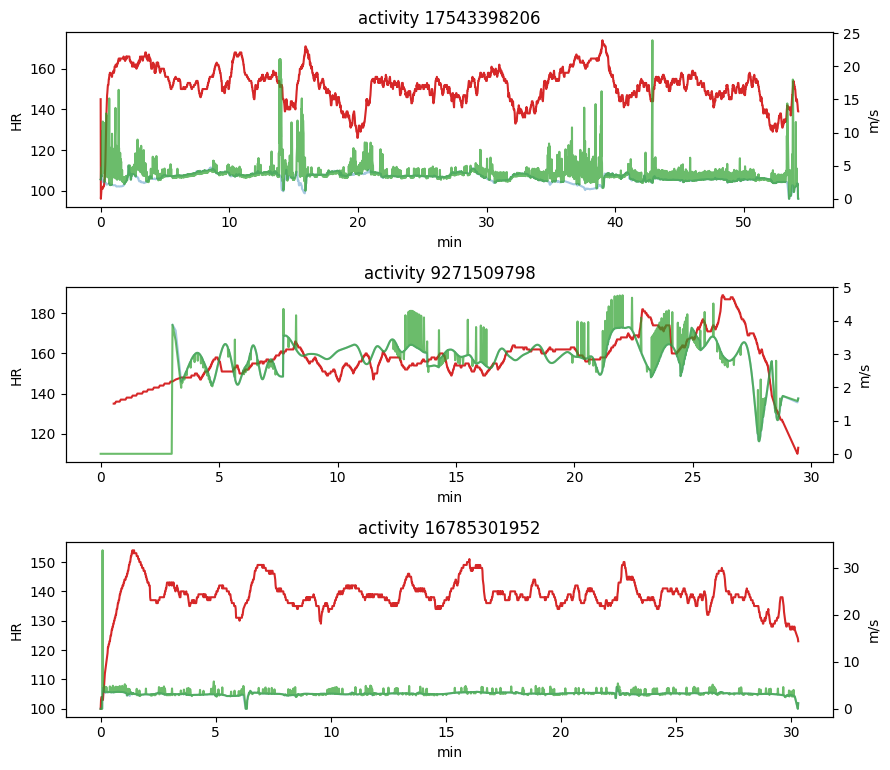

In [10]:
import matplotlib.pyplot as plt

sample_ids = (streams[streams["discipline"] == "running"]
              .drop_duplicates("activity_id")["activity_id"]
              .sample(min(3, streams["activity_id"].nunique()), random_state=0).tolist())

fig, axes = plt.subplots(len(sample_ids), 1, figsize=(9, 2.6*len(sample_ids)), sharex=False)
if len(sample_ids) == 1: axes = [axes]
for ax, aid in zip(axes, sample_ids):
    s = streams[streams["activity_id"] == aid]
    ax2 = ax.twinx()
    ax.plot(s["elapsed_s"]/60, s["hr_bpm"],         color="tab:red", label="HR (bpm)")
    ax2.plot(s["elapsed_s"]/60, s["speed_mps"],     color="tab:blue", alpha=0.4, label="speed")
    ax2.plot(s["elapsed_s"]/60, s["gap_speed_mps"], color="tab:green", alpha=0.7, label="GAP speed")
    ax.set_title(f"activity {aid}"); ax.set_xlabel("min")
    ax.set_ylabel("HR"); ax2.set_ylabel("m/s")
plt.tight_layout(); plt.show()
